Done. X-axis is now integers.


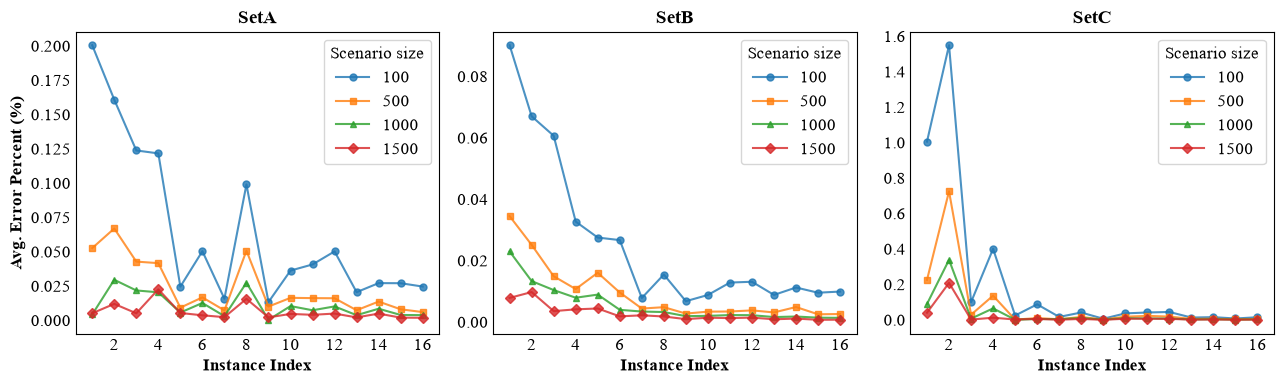

In [18]:
import os
import re
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 【修改处 1】引入 ticker 用于控制坐标轴刻度
from matplotlib.ticker import MaxNLocator 

# =========================
# 配置区域
# =========================
INSTANCE_FILE = Path("instance3.txt")

# 设置学术字体 (Times New Roman)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12

SCENARIO_DIRS = {
    100: Path("SampleSize/S100"),
    500: Path("SampleSize/S500"),
    1000: Path("SampleSize/S1000"),
    1500: Path("SampleSize/S1500"),
}

OUTPUT_INSTANCE_CSV = Path("instance_level_summary.csv")
OUTPUT_FIG = Path("4.scenario_sensitivity_lines_by_instance.pdf")

SCENARIO_COLORS = {
    100: '#1f77b4',
    500: '#ff7f0e',
    1000: '#2ca02c',
    1500: '#d62728',
}

SCENARIO_MARKERS = {
    100: 'o', 
    500: 's', 
    1000: '^', 
    1500: 'D', 
}

# =========================
# 基础工具 (保持不变)
# =========================
def infer_set_name(instance_name: str) -> str:
    if instance_name.endswith("_MD"): return "SetB"
    if instance_name.endswith("_M"): return "SetA"
    if instance_name.endswith("_X"): return "SetC"
    return "Unknown"

def safe_float(x: str) -> float:
    try:
        v = float(x)
        if math.isnan(v) or math.isinf(v): return float("nan")
        return v
    except Exception: return float("nan")

def load_instances_in_order(instance_file: Path):
    all_instances = []
    try:
        content = instance_file.read_text(encoding="utf-8", errors="ignore")
    except FileNotFoundError: return {}
    for ln in content.splitlines():
        if ln.strip(): all_instances.append(ln.strip())
    set_to_instances = {"SetA": [], "SetB": [], "SetC": []}
    for inst in all_instances:
        s = infer_set_name(inst)
        if s in set_to_instances: set_to_instances[s].append(inst)
    return set_to_instances

def parse_samsta_file(file_path: Path):
    try: txt = file_path.read_text(encoding="utf-8", errors="ignore").strip()
    except Exception: return []
    if not txt: return []
    blocks = [b.strip() for b in txt.split("********") if b.strip()]
    runs = []
    for b in blocks:
        lines = [ln.strip() for ln in b.splitlines() if ln.strip()]
        if not lines: continue
        m = re.match(r"^\s*(\d+)\s+(\d+)\s*$", lines[0])
        if not m: continue
        err_cnt, total_cnt = int(m.group(1)), int(m.group(2))
        err_rate = 0.0 if total_cnt == 0 else err_cnt / total_cnt
        ave_rate = float("nan")
        for ln in lines[1:]:
            if ln.lower().startswith("averegretrate"):
                parts = ln.split(":")
                if len(parts) >= 2: ave_rate = safe_float(parts[1].strip())
                break
        err_percent = 0.0 if (err_cnt == 0 or math.isnan(ave_rate)) else ave_rate * 100.0
        runs.append({"err_cnt": err_cnt, "total_cnt": total_cnt, "err_rate": err_rate, "err_percent": err_percent})
    return runs

def aggregate_over_runs(runs, mode="mean_of_ratios"):
    if not runs: return (float("nan"), float("nan"))
    if mode == "ratio_of_sums":
        total_err = sum(r["err_cnt"] for r in runs)
        total_tot = sum(r["total_cnt"] for r in runs)
        avg_err_rate = 0.0 if total_tot == 0 else total_err / total_tot
    else:
        avg_err_rate = float(np.mean([r["err_rate"] for r in runs]))
    avg_err_percent = float(np.mean([r["err_percent"] for r in runs]))
    return (avg_err_rate, avg_err_percent)

# =========================
# 主函数
# =========================
def main():
    set_to_instances = load_instances_in_order(INSTANCE_FILE)
    if not set_to_instances: return

    scenario_sizes = sorted(SCENARIO_DIRS.keys())
    rows, missing = [], []

    # 数据处理
    for set_name, inst_list in set_to_instances.items():
        for scen in scenario_sizes:
            base_dir = SCENARIO_DIRS[scen]
            for idx, inst in enumerate(inst_list, start=1):
                f = base_dir / f"{inst}_sol_SamSta.txt"
                if not f.exists():
                    missing.append(str(f))
                    avg_rate, avg_pct, n_runs = float("nan"), float("nan"), 0
                else:
                    runs = parse_samsta_file(f)
                    n_runs = len(runs)
                    if n_runs == 0:
                        missing.append(str(f))
                        avg_rate, avg_pct = float("nan"), float("nan")
                    else:
                        avg_rate, avg_pct = aggregate_over_runs(runs)
                rows.append({"set": set_name, "scenario": scen, "instance_index": idx,
                             "instance": inst, "n_runs": n_runs, "avg_err_rate": avg_rate, "avg_err_percent": avg_pct})

    df = pd.DataFrame(rows)
    df.to_csv(OUTPUT_INSTANCE_CSV, index=False, encoding="utf-8-sig")

    # --- 画图逻辑 ---
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False) 
    sets_order = ["SetA", "SetB", "SetC"]

    for col, set_name in enumerate(sets_order):
        inst_list = set_to_instances[set_name]
        x = np.arange(1, len(inst_list) + 1)
        ax = axes[col]

        for scen in scenario_sizes:
            sub = df[(df["set"] == set_name) & (df["scenario"] == scen)].sort_values("instance_index")
            y_pct = sub["avg_err_percent"].to_numpy()

            ax.plot(x, y_pct, 
                    color=SCENARIO_COLORS.get(scen, 'black'), 
                    marker=SCENARIO_MARKERS.get(scen, 'o'), 
                    markersize=5,
                    linewidth=1.5,
                    alpha=0.8,
                    label=str(scen))

        ax.set_title(f"{set_name}", fontsize=14, fontweight='bold')
        if col == 0:
            ax.set_ylabel("Avg. Error Percent (%)", fontsize=12, fontweight='bold')
        ax.set_xlabel("Instance Index", fontsize=12, fontweight='bold')
        
        # 去掉网格和刻度线
        ax.grid(False)
        ax.tick_params(axis='both', which='both', length=0)

        # 【修改处 2】强制横坐标显示整数
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        ax.legend(title="Scenario size")

    plt.tight_layout()
    plt.savefig(OUTPUT_FIG, dpi=300)
    print("Done. X-axis is now integers.")

if __name__ == "__main__":
    main()

图片已保存


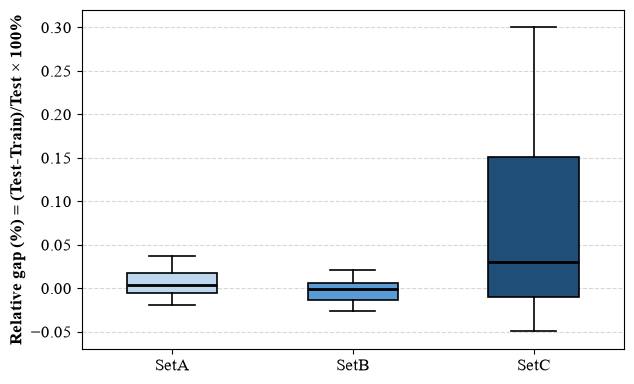

In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CSV_PATH = "SamplexSize.csv"
CAP = 0.32      # 上界（%）
CAP2 = 0.07    # 下界绝对值（%），y轴下限为 -CAP2

# 三组箱体填充色
FACE_COLORS = ['#BDD7EE', '#5B9BD5', '#1F4E79']  # SetA, SetB, SetC

# Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12

# =========================
# 解析 Set：例如 10x3A -> A
# =========================
def parse_set(instance_name: str) -> str:
    s = str(instance_name).strip()
    m = re.match(r"^\s*\d+\s*x\s*\d+\s*([A-Za-z])\s*$", s)
    return m.group(1).upper() if m else "UNK"


df = pd.read_csv(CSV_PATH, sep=None, engine="python")
df.columns = [c.strip() for c in df.columns]

for col in ["Instances", "Train", "Test"]:
    if col not in df.columns:
        raise ValueError(f"Missing column '{col}'. Found: {list(df.columns)}")

df["Set"] = df["Instances"].apply(parse_set)
df["Train"] = pd.to_numeric(df["Train"], errors="coerce")
df["Test"]  = pd.to_numeric(df["Test"], errors="coerce")
df = df.dropna(subset=["Train", "Test"])

# =========================
# 带符号相对误差 g(%)
# g = (Test - Train) / Test * 100%
# =========================
df["g_pct"] = (df["Test"] - df["Train"]) / df["Test"] * 100.0

# 只保留 A/B/C
df = df[df["Set"].isin(["A", "B", "C"])].copy()

sets = ["A", "B", "C"]
labels = [f"Set{s}" for s in sets]

data_all = []
# 这里去掉了 out_pos / out_neg 的计算，因为不需要再画它们了

for s in sets:
    vals = df.loc[df["Set"] == s, "g_pct"].dropna().values
    if len(vals) == 0:
        vals = np.array([0.0])
    data_all.append(vals)

fig, ax = plt.subplots(figsize=(6.5, 4))

bp = ax.boxplot(
    data_all,
    tick_labels=labels,
    showfliers=False,   # 这里已经隐藏了统计学意义上的离群点（圆点）
    widths=0.5,
    patch_artist=True,  # 允许填充色
    medianprops=dict(color="black", linewidth=2.0),
    boxprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2)
)

# 给每个箱体设置填充色
for box, fc in zip(bp["boxes"], FACE_COLORS):
    box.set_facecolor(fc)
    box.set_alpha(1.0) 

ax.set_ylabel("Relative gap (%) = (Test-Train)/Test × 100%", fontweight='bold')
ax.set_ylim(-CAP2, CAP) # 超出这个范围的数据会被截断且不显示
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("4.2boxPlot_clean.pdf", dpi=300, bbox_inches='tight')
print("图片已保存")
plt.show()


Outliers (|g| > 1%):
Instances Set   Train   Test     g_pct  abs_g_pct
    10x4C   C   17.00   23.2 26.724138  26.724138
    10x3C   C   43.81   51.2 14.433594  14.433594
    15x4C   C  374.60  353.4 -5.998868   5.998868
    20x4C   C 5248.03 5193.2 -1.055804   1.055804

Saved figures to: 4.2Train_vs_Test_and_GapPlots.pdf


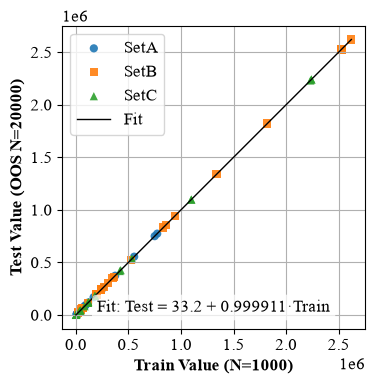

In [17]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

CSV_PATH = "SamplexSize.csv"
SAVE_TO_PDF = True
PDF_PATH = "4.2Train_vs_Test_and_GapPlots.pdf"

# Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12

MAIN_YMAX_DEFAULT = 0.5   # 下图：展示主体 |g| 的上限（%）
TAIL_YMIN_DEFAULT = 5.0   # 上图：展示离群点的下限（%）



def read_sample_csv(path: str) -> pd.DataFrame:
    # 尝试自动分隔符推断
    try:
        df = pd.read_csv(path, sep=None, engine="python")
        return df
    except Exception:
        pass

    # 兜底：尝试 tab / comma
    for sep in ["\t", ","]:
        try:
            df = pd.read_csv(path, sep=sep)
            return df
        except Exception:
            continue

    raise RuntimeError(f"Cannot read file: {path}. Please check delimiter/encoding.")


# =========================
# 解析实例名：10x3A -> Jobs=10, Machines=3, Set=A
# =========================
def parse_instance(name: str):
    name = str(name).strip()
    m = re.match(r"(\d+)\s*x\s*(\d+)\s*([A-Za-z])$", name)
    if m:
        return int(m.group(1)), int(m.group(2)), m.group(3).upper()
    return np.nan, np.nan, "UNK"


# =========================
# 计算指标：Delta, g(%), |g|(%)
# =========================
def add_metrics(df: pd.DataFrame) -> pd.DataFrame:
    # 标准化列名
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    # 保证必须列存在
    for col in ["Instances", "Train", "Test"]:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}. Found columns: {list(df.columns)}")

    # 解析 Instances
    parsed = df["Instances"].apply(parse_instance)
    df["Jobs"] = [p[0] for p in parsed]
    df["Machines"] = [p[1] for p in parsed]
    df["Set"] = [p[2] for p in parsed]

    # 数值化
    df["Train"] = pd.to_numeric(df["Train"], errors="coerce")
    df["Test"] = pd.to_numeric(df["Test"], errors="coerce")
    df = df.dropna(subset=["Train", "Test"])

    # gap
    df["Delta"] = df["Test"] - df["Train"]
    df["g_pct"] = df["Delta"] / df["Test"] * 100.0
    df["abs_g_pct"] = df["g_pct"].abs()
    df["mean_level"] = (df["Train"] + df["Test"]) / 2.0
    return df


# =========================
# 图1：Train vs Test 散点图（y=x + 回归线 + 指标）
# =========================
def plot_scatter_train_test(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(5, 4))

    # 颜色与形状（你可以按喜好改色）
    color_map  = {"A": "#1f77b4", "B": "#ff7f0e", "C": "#2ca02c", "UNK": "black"}
    marker_map = {"A": "o", "B": "s", "C": "^", "UNK": "x"}

    # 计算绘图范围（用于 y=x 和回归线端点）
    mn = min(df["Train"].min(), df["Test"].min())
    mx = max(df["Train"].max(), df["Test"].max())

    # 按 Set 分组画散点（这里改颜色）
    for s, d in df.groupby("Set", sort=True):
        mk = marker_map.get(s, "o")
        col = color_map.get(s, "black")
        ax.scatter(
            d["Train"], d["Test"],
            s=35, marker=mk,
            color=col, alpha=0.9,
            edgecolors="none",   # 若想更清晰边界可改成 edgecolors="black", linewidths=0.3
            label=f"Set{s}"
        )

    # 线性回归：Test = a + b*Train
    x = df["Train"].values
    y = df["Test"].values
    b, a = np.polyfit(x, y, 1)

    # 回归线
    xx = np.array([mn, mx])
    yy = a + b * xx
    ax.plot(xx, yy, color="black", linewidth=1.0, label="Fit")

    # 文本放底部中间（你设的是 0.5, 0.1）
    text = f"Fit: Test = {a:.3g} + {b:.6f}·Train"
    ax.text(
        0.5, 0.07, text,
        transform=ax.transAxes,
        va="center", ha="center",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none")
    )

    ax.set_xlabel("Train Value (N=1000)", fontweight='bold')
    ax.set_ylabel("Test Value (OOS N=20000)", fontweight='bold')
    ax.grid(True)

    # 图例（如果你觉得 y=x 和 Fit 也进图例太乱，可以把它们 label 改成 "_nolegend_")
    ax.legend()

    ax.set_aspect("equal", adjustable="box")
    fig.tight_layout()
    return fig

# =========================
# 主程序
# =========================
def main():
    df0 = read_sample_csv(CSV_PATH)
    df = add_metrics(df0)

    # 输出：找出明显离群点（你也可以把阈值改成 1% 或 0.5%）
    out = df[df["abs_g_pct"] > 1.0].sort_values("abs_g_pct", ascending=False)
    if len(out) > 0:
        print("\nOutliers (|g| > 1%):")
        print(out[["Instances", "Set", "Train", "Test", "g_pct", "abs_g_pct"]].to_string(index=False))
    else:
        print("\nNo outliers found with |g| > 1% threshold.")

    fig1 = plot_scatter_train_test(df)

    if SAVE_TO_PDF:
        with PdfPages(PDF_PATH) as pdf:
            pdf.savefig(fig1)
        print(f"\nSaved figures to: {PDF_PATH}")

    plt.show()


if __name__ == "__main__":
    main()
